## PREPROCESSING AND CLEANING OF DATASET

In [1]:
# Importing Packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Importing data set
sleep_analysis = pd.read_csv("Sleep dataset.csv", keep_default_na = False)
print(sleep_analysis)

    body_weight  brain_weight max_life_span gestation_time  predation_index  \
0      6654.000        5712.0          38.6            645                3   
1         1.000           6.6           4.5             42                3   
2         3.385          44.5            14             60                1   
3         0.920           5.7             ?             25                5   
4      2547.000        4603.0            69            624                3   
..          ...           ...           ...            ...              ...   
57        2.000          12.3           7.5            200                3   
58        0.104           2.5           2.3             46                3   
59        4.190          58.0            24            210                4   
60        3.500           3.9             3             14                2   
61        4.050          17.0            13             38                3   

    sleep_exposure_index  danger_index total_sleep 

In [3]:
cunt_class = sleep_analysis.groupby('brain_weight').size()
cunt_class.head(7)

brain_weight
0.14    1
0.25    1
0.30    1
0.33    1
0.40    1
1.00    2
1.20    1
dtype: int64

In [4]:
sleep_analysis.dtypes

body_weight             float64
brain_weight            float64
max_life_span            object
gestation_time           object
predation_index           int64
sleep_exposure_index      int64
danger_index              int64
total_sleep              object
dtype: object

In [5]:
for col in ['total_sleep', 'gestation_time', 'max_life_span']:
    sleep_analysis[col] = pd.to_numeric(sleep_analysis[col], errors='coerce')

sleep_analysis1= sleep_analysis.dropna(subset=['body_weight', 'sleep_exposure_index', 
                             'predation_index', 'danger_index', 'total_sleep']).copy()

In [6]:
sleep_analysis1.dtypes

body_weight             float64
brain_weight            float64
max_life_span           float64
gestation_time          float64
predation_index           int64
sleep_exposure_index      int64
danger_index              int64
total_sleep             float64
dtype: object

In [7]:
# Correlation between attributes
correlations = sleep_analysis1.corr(method='pearson')
correlations

,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
body_weight,1.000000,0.934171,0.299138,0.687339,0.051987,0.356018,0.129781,-0.307186
brain_weight,0.934171,1.000000,0.506030,0.782844,0.019952,0.382633,0.136194,-0.358102
max_life_span,0.299138,0.506030,1.000000,0.637472,-0.123217,0.370894,0.042181,-0.410202
gestation_time,0.687339,0.782844,0.637472,1.000000,0.120388,0.634077,0.311149,-0.631326
predation_index,0.051987,0.019952,-0.123217,0.120388,1.000000,0.603212,0.928272,-0.395835
sleep_exposure_index,0.356018,0.382633,0.370894,0.634077,0.603212,1.000000,0.758241,-0.642285
danger_index,0.129781,0.136194,0.042181,0.311149,0.928272,0.758241,1.000000,-0.587742
total_sleep,-0.307186,-0.358102,-0.410202,-0.631326,-0.395835,-0.642285,-0.587742,1.000000


In [8]:
sleep_analysis1.describe()

,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
count,58.000000,58.000000,54.000000,54.000000,58.000000,58.000000,58.000000,58.000000
mean,198.395328,281.229655,19.851852,136.027778,2.793103,2.310345,2.534483,10.532759
std,928.507308,959.418957,18.810723,140.649719,1.472063,1.535623,1.391900,4.606760
min,0.005000,0.140000,2.000000,12.000000,1.000000,1.000000,1.000000,2.600000
25%,0.497500,3.925000,6.125000,36.750000,2.000000,1.000000,1.000000,8.050000
50%,2.750000,14.000000,13.850000,79.000000,2.500000,2.000000,2.000000,10.450000
75%,34.162500,147.625000,27.750000,195.000000,4.000000,3.750000,4.000000,13.200000
max,6654.000000,5712.000000,100.000000,645.000000,5.000000,5.000000,5.000000,19.900000


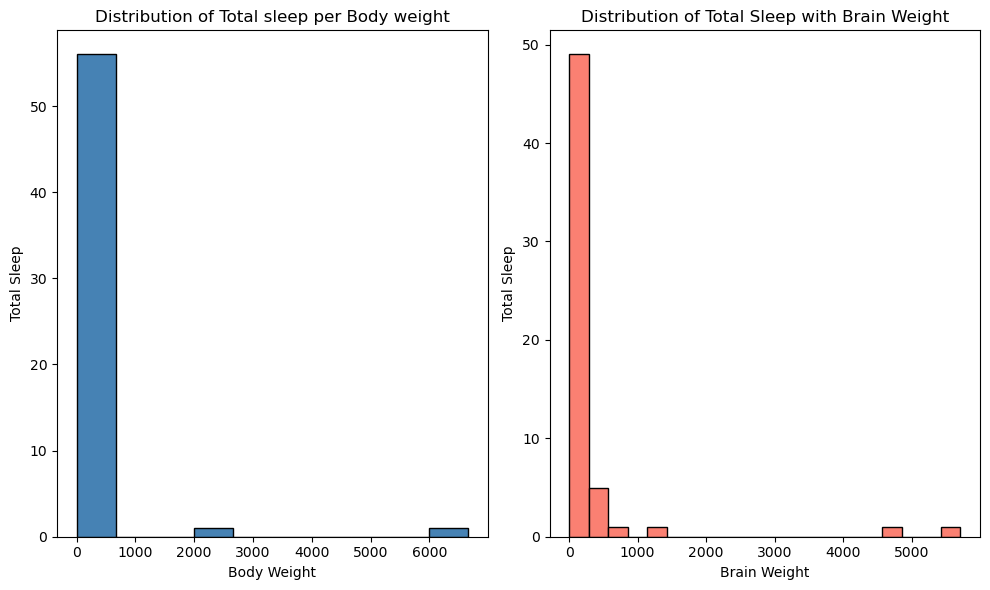

In [9]:
# Plotting Histogram showing relationship between body weight and total sleep,  and also brain weight and sleep
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.hist(sleep_analysis1.body_weight,
        color = "SteelBlue", edgecolor = "black")
plt.title("Distribution of Total sleep per Body weight")
plt.xlabel('Body Weight')
plt.ylabel('Total Sleep')

plt.subplot(1, 2, 2)
plt.hist(sleep_analysis1.brain_weight, bins=20, color = "salmon", edgecolor = "black")
plt.title('Distribution of Total Sleep with Brain Weight')
plt.xlabel('Brain Weight')
plt.ylabel('Total Sleep')
plt.tight_layout()

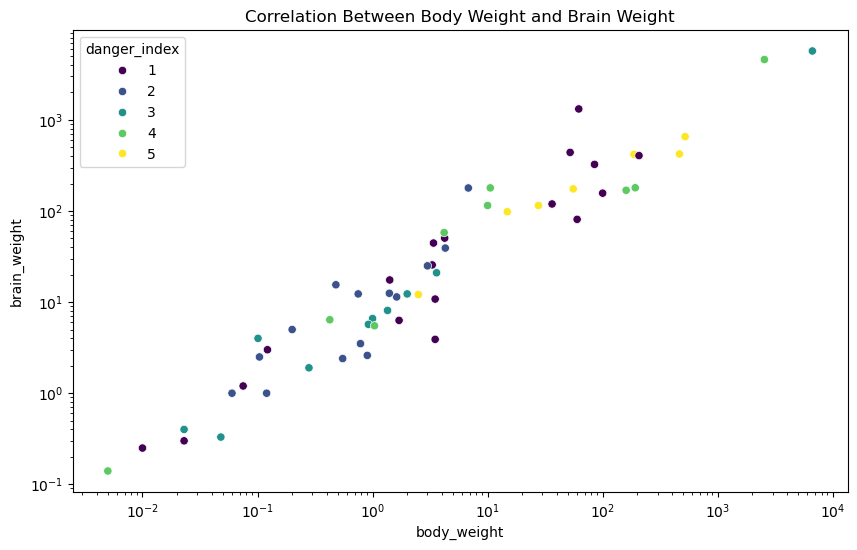

In [10]:
plt.figure(figsize = (10, 6))
sns.scatterplot(data = sleep_analysis1,
                x = 'body_weight',
                y = 'brain_weight', 
                hue = 'danger_index',
               palette = 'viridis')
plt.xscale('log')
plt.yscale('log')
plt.title('Correlation Between Body Weight and Brain Weight');


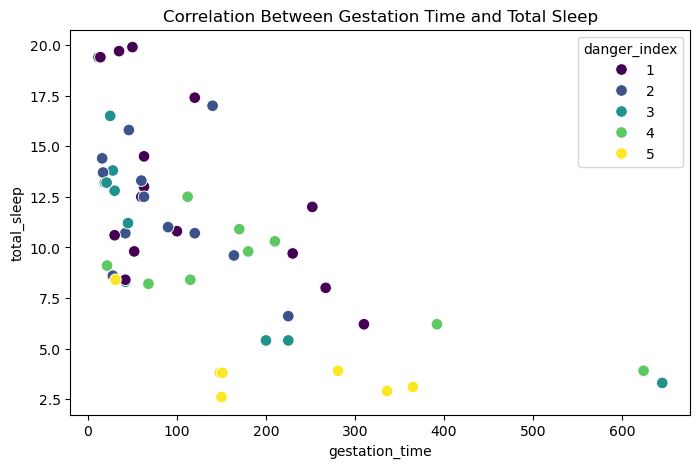

In [11]:
sleep_analysis1['gestation_time'] = pd.to_numeric(sleep_analysis1['gestation_time'], errors='coerce')
sleep_analysis1['total_sleep'] = pd.to_numeric(sleep_analysis1['total_sleep'], errors='coerce')
plt.figure(figsize = (8, 5))
sns.scatterplot(data = sleep_analysis1,
                x = 'gestation_time',
                y = 'total_sleep', 
                hue = 'danger_index',
                palette = 'viridis',
               s = 70)
plt.title('Correlation Between Gestation Time and Total Sleep');

## BUILDING MODEL 

In [12]:
# Splitting of dataset to training and testing sets
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
sleep_analysis1['log_body'] = np.log10(sleep_analysis['body_weight'])
X = sleep_analysis1[['log_body']]
y = sleep_analysis1[['sleep_exposure_index', 'predation_index', 'danger_index', 'total_sleep']]
X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.4,random_state=42)

In [13]:
# Training model
model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', MultiOutputRegressor(KNeighborsRegressor(n_neighbors=5, weights = 'distance')))
])
model.fit(X,y)


,steps,"[('scaler', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimator,KNeighborsReg...ts='distance')
,n_jobs,None
,n_neighbors,5
,weights,'distance'


In [18]:
# Making Predictions

def predict_mammal_metrics(body_weight):
    log_body = np.array([[np.log10(body_weight)]])
    prediction = model.predict(log_body)[0]
    return {
        'Input Body Weight(kg)': body_weight,
        'Predicted Sleep Exposure Index (1-5)': int(np.clip(np.round(prediction[0]), 1, 5)),
        'Predicted Predation Index (1-5)': int(np.clip(np.round(prediction[1]), 1, 5)),
        'Predicted Danger Index (1-5)': int(np.clip(np.round(prediction[2]), 1, 5)),
        'Predicted Total Sleep (hrs/day)': round(prediction[3], 2)
    }
print(predict_mammal_metrics(body_weight=5.2))
import warnings
warnings.filterwarnings('ignore')

{'Input Body Weight(kg)': 5.2, 'Predicted Sleep Exposure Index (1-5)': 2, 'Predicted Predation Index (1-5)': 2, 'Predicted Danger Index (1-5)': 2, 'Predicted Total Sleep (hrs/day)': np.float64(9.97)}


In [15]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Get predictions for your dataset
y_true = y  # Actual total_sleep values from your dataset
y_pred = model.predict(X)  # Predictions from your trained Ridge model

# 2. Calculate Evaluation Metrics
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"R² Score: {r2:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f} hours")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} hours")

R² Score: 0.98
Mean Absolute Error (MAE): 0.06 hours
Root Mean Squared Error (RMSE): 0.36 hours
